# DESCRIPTION

Analysis of the production of de novo designed B22 protein.

In [1]:
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rms
from prody import *

/home/davidelu/mambaforge/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## PROD2

md_aligned.dcd is the gromacs trajectory aligned to the starting structure (prot_b22.pdb) in VMD. 

### Structure

In [2]:
%cd PROD2

/mnt/c/Users/davidelu/OneDrive - NTNU/PhD/Papers/papers/2025/Vnat_denovo/MD_simulation/PROD2


In [10]:
!unzip md_aligned.zip

Archive:  md_aligned.zip
error:  cannot create md_aligned.dcd
        No such file or directory


In [11]:
u = mda.Universe("prot_b22.pdb", "md_aligned.dcd")
reference = mda.Universe("prot_b22.pdb")


In [12]:
cterm = u.select_atoms("backbone and resid 250-274")
cterm_ref=reference.select_atoms("backbone and resid 250-274")
R_cter = rms.RMSD(cterm,cterm_ref)
R_cter.run()

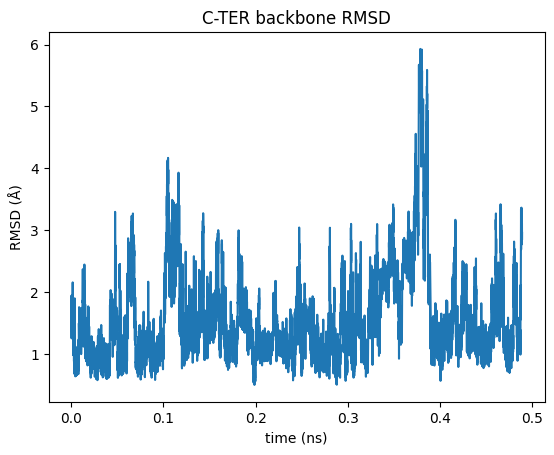

In [13]:
plt.plot(R_cter.rmsd[:, 1]*1e-3, R_cter.rmsd[:, 2])
plt.xlabel("time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("C-TER backbone RMSD")
plt.show()

In [14]:
no_cterm = u.select_atoms("backbone and not resid 250-274")
no_cterm_ref = reference.select_atoms("backbone and not resid 250-274")
R_nocterm = rms.RMSD(no_cterm,no_cterm_ref)
R_nocterm.run()

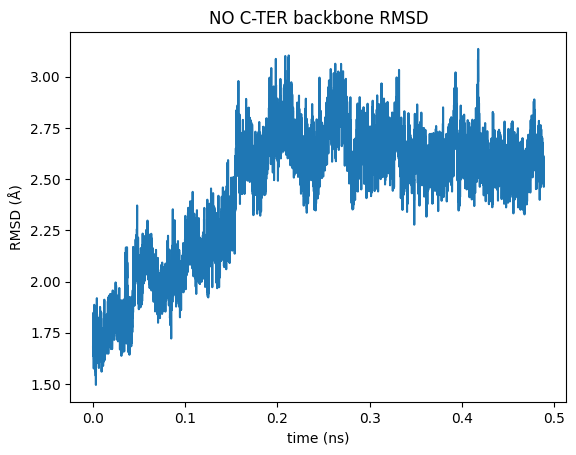

In [15]:
plt.plot(R_nocterm.rmsd[:, 1]*1e-3, R_nocterm.rmsd[:, 2])
plt.xlabel("time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("NO C-TER backbone RMSD")
plt.show()

In [15]:
binding = u.select_atoms("resid 21 103 132")
catal = u.select_atoms("resid 218 189 102")

In [16]:
R_bind = rms.RMSD(binding, ref_positions=reference.select_atoms("resid 21 103 132").positions)
R_bind.run()

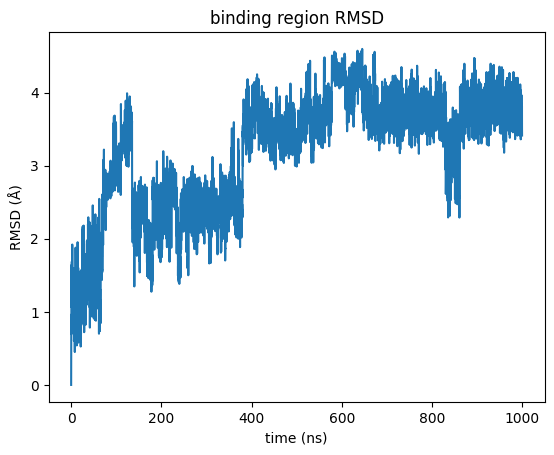

In [17]:
plt.plot(R_bind.rmsd[:, 1]*1e-3, R_bind.rmsd[:, 2])
plt.xlabel("time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("binding region RMSD")
plt.show()

In [18]:
R_catal = rms.RMSD(catal, ref_positions=reference.select_atoms("resid 218 189 102").positions)
R_catal.run()

/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/analysis/rms.py:722: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


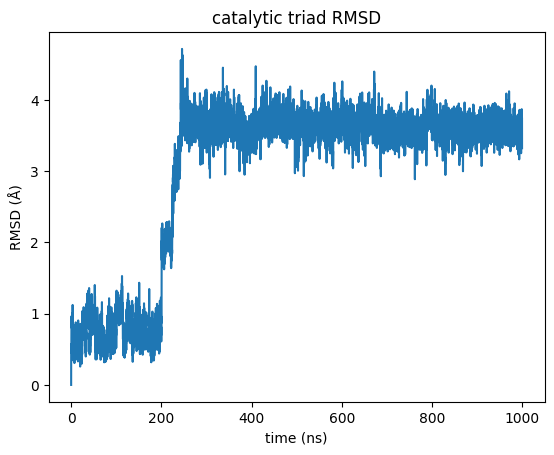

In [34]:
plt.plot(R_catal.rmsd[:, 1]*1e-3, R_catal.rmsd[:, 2])
plt.xlabel("time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("catalytic triad RMSD")
plt.show()

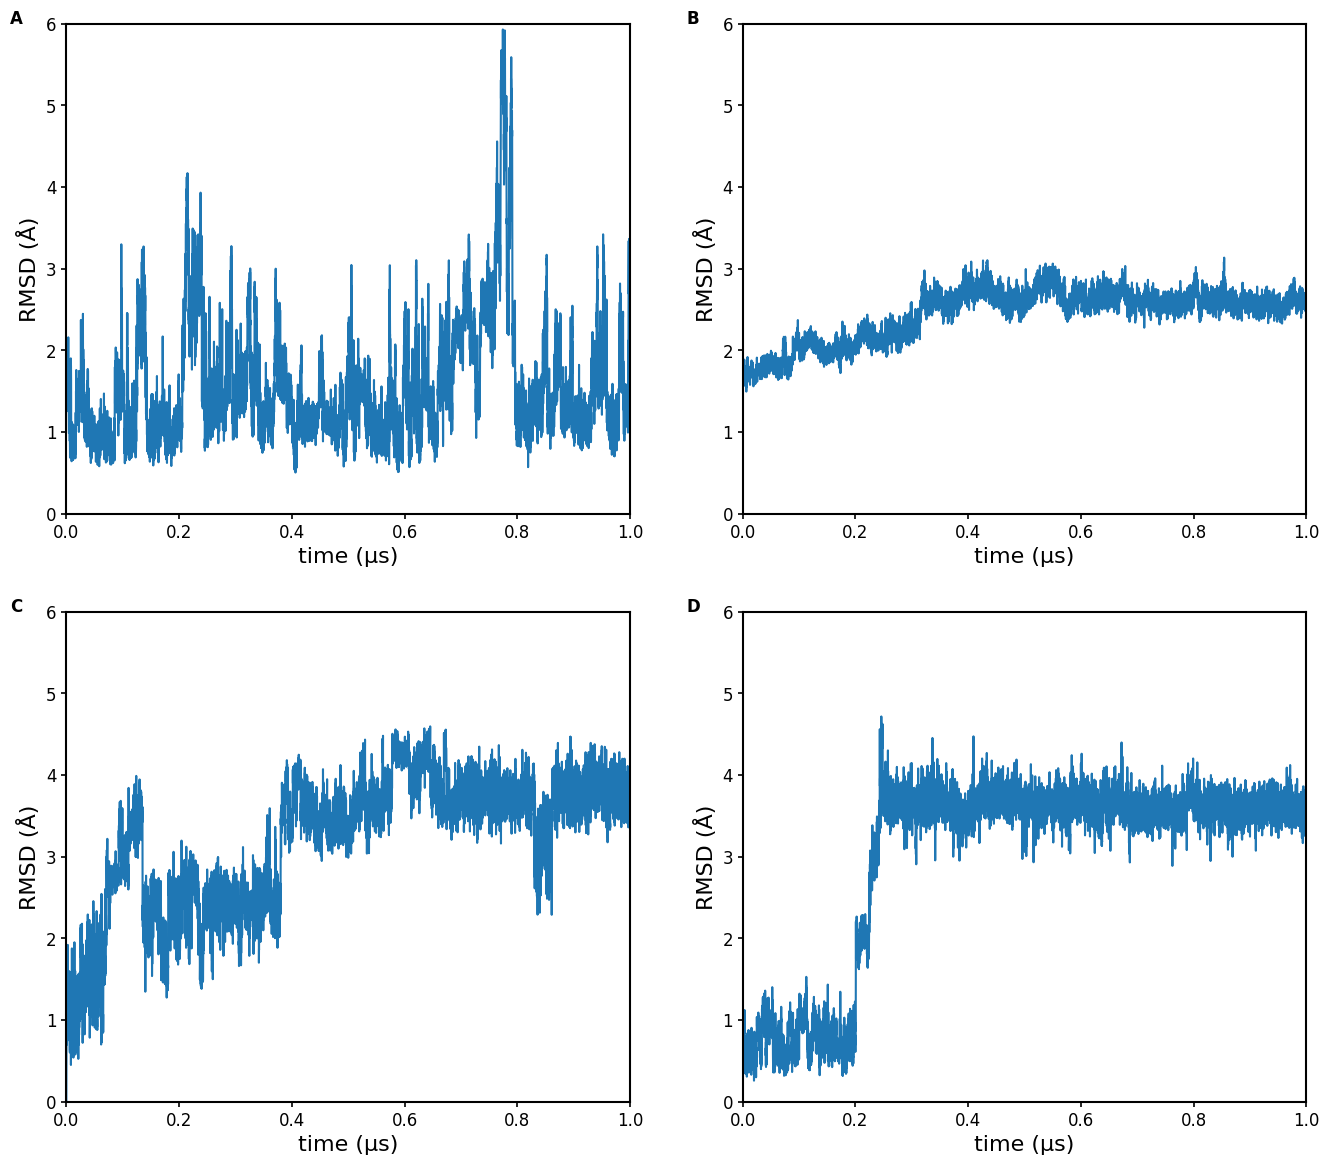

In [19]:
import matplotlib as mpl


mpl.rcParams.update({
    "font.family": "DejaVu Sans",  
    "font.size": 16,               
    "axes.labelsize": 14,                  
    "xtick.labelsize": 12,         
    "ytick.labelsize": 12,              
    "axes.linewidth": 1.5,         
    "xtick.major.width": 1.2,      
    "ytick.major.width": 1.2,
})

time =R_catal.rmsd[:, 1]*1e-6

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

dati = [R_cter.rmsd[:, 2], R_nocterm.rmsd[:, 2], R_bind.rmsd[:, 2], R_catal.rmsd[:, 2]]
lettere = ["A", "B", "C", "D"]

for ax, rmsd, lettera in zip(axes.flat, dati, lettere):
    ax.plot(time, rmsd)
    ax.set_xlabel("time (μs)")
    ax.set_ylabel("RMSD (Å)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 6)
    ax.text(-0.1, 1., lettera, transform=ax.transAxes, fontsize=12, fontweight='bold')


plt.savefig("rmsds.png", bbox_inches="tight", dpi=300)
plt.show()


### Essential dynamic analysis

In [23]:
%cd PROD2

[Errno 2] No such file or directory: 'PROD2'
/mnt/d/PhD/Notebook/Paper2/PROD2


In [24]:
structure = parsePDB('prot_b22.pdb')
dcd_free = parseDCD('md_aligned.dcd')

@> 3962 atoms and 1 coordinate set(s) were parsed in 0.05s.


@> DCD file contains 10001 coordinate sets for 3962 atoms.
@> DCD file was parsed in 4.73 seconds.
@> 454.22 MB parsed at input rate 96.11 MB/s.
@> 10001 coordinate sets parsed at input rate 2116 frame/s.


In [25]:
dcd_free.setCoords(structure)
dcd_free.setAtoms(structure.calpha)

In [26]:
eda_trajectory = EDA('MDM2 Trajectory')

In [27]:
eda_trajectory.buildCovariance( dcd_free )

@> Covariance is calculated using 10001 coordinate sets.
@> Covariance matrix calculated in 33.927097s.


In [28]:
eda_trajectory.calcModes()

@> 20 modes were calculated in 0.11s.


In [29]:
writeNMD('md_eda.nmd', eda_trajectory, structure.select('calpha'))

'md_eda.nmd'

In [30]:
saveModel(eda_trajectory)

'MDM2_Trajectory.eda.npz'